설정                            Model1 (mean±std)  Model2 (mean±std)
  FNO   (solo)               0.0891 ± 0.0021
  DeepONet (solo)            0.1853 ± 0.0024
  GNOT  (solo)               0.2333 ± 0.0084
-----------------------------------------------------------------
  FNO+FNO   (SSML)           0.0829 ± 0.0020   0.0829 ± 0.0020
  FNO+DON   (SSML)           0.0860 ± 0.0019   0.1724 ± 0.0036
  FNO+GNOT  (SSML)           0.0851 ± 0.0025   0.1860 ± 0.0101
  DON+DON   (SSML)           0.1776 ± 0.0039   0.1776 ± 0.0039
  DON+GNOT  (SSML)           0.1809 ± 0.0046   0.1825 ± 0.0136
  GNOT+GNOT (SSML)           0.1760 ± 0.0040   0.1760 ± 0.0040
-----------------------------------------------------------------
  FNO+FNO   (DML)            0.0883 ± 0.0013   0.0883 ± 0.0013
  FNO+DON   (DML)            0.0984 ± 0.0018   0.1794 ± 0.0032
  FNO+GNOT  (DML)            0.1111 ± 0.0023   0.2077 ± 0.0026
  DON+DON   (DML)            0.1852 ± 0.0020   0.1852 ± 0.0020
  DON+GNOT  (DML)            0.1866 

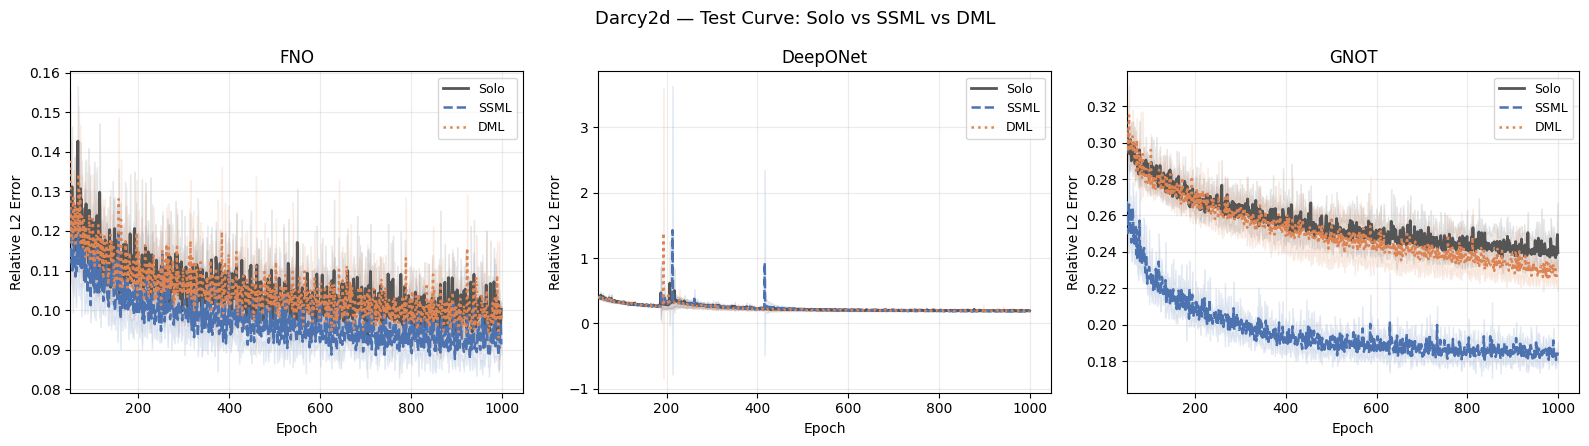

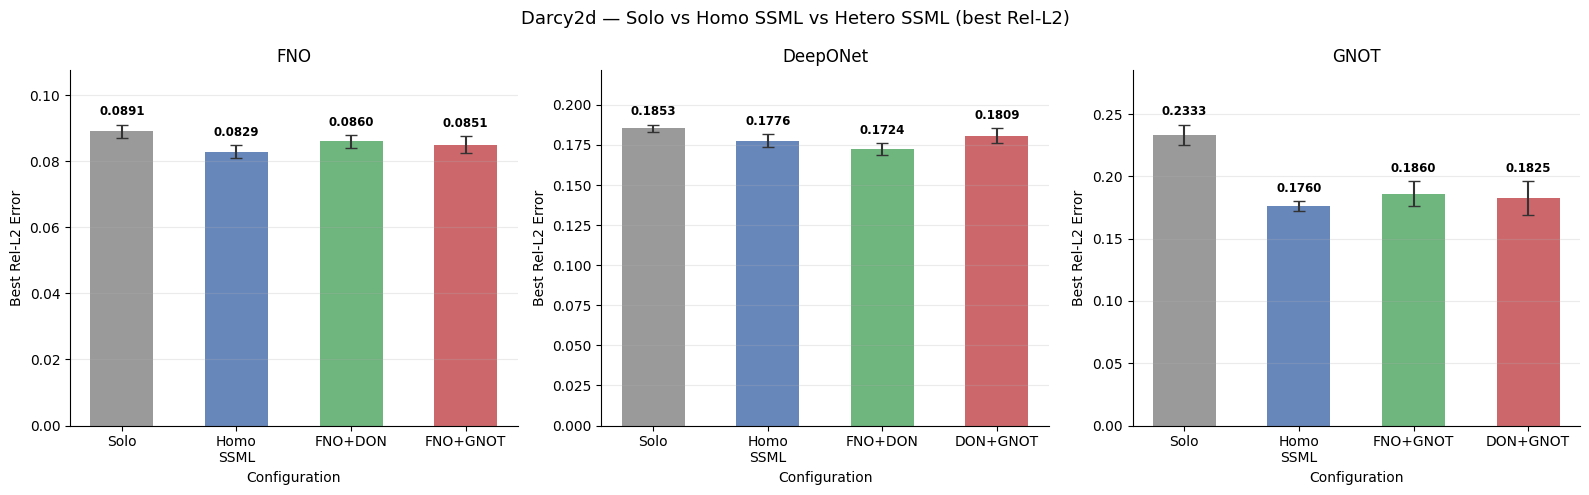

In [5]:
import csv
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ================================================================
# 1. CSV 로드 헬퍼
# ================================================================
def load_csv(filepath, is_dual=False):
    results = []
    with open(filepath, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            r = {}
            for k, v in row.items():
                try:
                    r[k] = ast.literal_eval(v)   # list/float 자동 변환
                except:
                    r[k] = v
            # numpy 변환
            for k in r:
                if isinstance(r[k], list):
                    r[k] = np.array(r[k])
            results.append(r)
    return results

# ================================================================
# 2. 통계 헬퍼
# ================================================================
def stats(results, key):
    """seed별 best 값 → (mean, std)"""
    vals = [r[key] for r in results]
    return np.mean(vals), np.std(vals)

def curve_stats(results, key):
    """seed별 curve → (mean_curve, std_curve)"""
    curves = np.stack([r[key] for r in results])
    return curves.mean(0), curves.std(0)

# ================================================================
# 3. 데이터 로드 — Burgers1D & Darcy
# ================================================================
# BASE = Path('results/burgers1d')
BASE = Path('results/darcy2d')

# 단일 모델
r_fno   = load_csv(BASE / 'experiment_results_fno.csv')
r_don   = load_csv(BASE / 'experiment_results_deeponet.csv')
r_gnot  = load_csv(BASE / 'experiment_results_gnot.csv')

# SSML 쌍
r_ff    = load_csv(BASE / 'experiment_results_fno_fno_ssml.csv')
r_fd    = load_csv(BASE / 'experiment_results_fno_deeponet_ssml.csv')
r_fg    = load_csv(BASE / 'experiment_results_fno_gnot_ssml.csv')
r_dd    = load_csv(BASE / 'experiment_results_deeponet_deeponet_ssml.csv')
r_dg    = load_csv(BASE / 'experiment_results_deeponet_gnot_ssml.csv')
r_gg    = load_csv(BASE / 'experiment_results_gnot_gnot_ssml.csv')

# DML 쌍 (있는 경우)
r_ff_dml = load_csv(BASE / 'experiment_results_fno_fno_dml.csv')
r_fd_dml = load_csv(BASE / 'experiment_results_fno_deeponet_dml.csv')
r_fg_dml = load_csv(BASE / 'experiment_results_fno_gnot_dml.csv')
r_dd_dml = load_csv(BASE / 'experiment_results_deeponet_deeponet_dml.csv')
r_dg_dml = load_csv(BASE / 'experiment_results_deeponet_gnot_dml.csv')
r_gg_dml = load_csv(BASE / 'experiment_results_gnot_gnot_dml.csv')

# ================================================================
# 4. 성능 비교표 출력
# ================================================================
print("=" * 65)
print(f"{'설정':<28} {'Model1 (mean±std)':>18} {'Model2 (mean±std)':>18}")
print("=" * 65)

# Baseline
for name, results in [("FNO   (solo)", r_fno),
                       ("DeepONet (solo)", r_don),
                       ("GNOT  (solo)", r_gnot)]:
    m, s = stats(results, 'best')
    print(f"  {name:<26} {m:.4f} ± {s:.4f}")

print("-" * 65)

# SSML
for name, results in [("FNO+FNO   (SSML)", r_ff),
                       ("FNO+DON   (SSML)", r_fd),
                       ("FNO+GNOT  (SSML)", r_fg),
                       ("DON+DON   (SSML)", r_dd),
                       ("DON+GNOT  (SSML)", r_dg),
                       ("GNOT+GNOT (SSML)", r_gg)]:
    m1, s1 = stats(results, 'best1')
    m2, s2 = stats(results, 'best2')
    print(f"  {name:<26} {m1:.4f} ± {s1:.4f}   {m2:.4f} ± {s2:.4f}")

print("-" * 65)

# DML
for name, results in [("FNO+FNO   (DML)", r_ff_dml),
                       ("FNO+DON   (DML)", r_fd_dml),
                       ("FNO+GNOT  (DML)", r_fg_dml),
                       ("DON+DON   (DML)", r_dd_dml),
                       ("DON+GNOT  (DML)", r_dg_dml),
                       ("GNOT+GNOT (DML)", r_gg_dml)]:
    m1, s1 = stats(results, 'best1')
    m2, s2 = stats(results, 'best2')
    print(f"  {name:<26} {m1:.4f} ± {s1:.4f}   {m2:.4f} ± {s2:.4f}")

print("=" * 65)

# ================================================================
# Figure 1 — 학습 곡선 (초반 spike 제거)
# ================================================================
WARMUP = 50   # 앞 50 epoch 제거 — 데이터 보고 조정

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
fig.suptitle("Darcy2d — Test Curve: Solo vs SSML vs DML", fontsize=13)

configs = [
    (axes[0], "FNO",      r_fno,  r_ff,   r_ff_dml, '1', '1'),
    (axes[1], "DeepONet", r_don,  r_dd,   r_dd_dml, '1', '1'),
    (axes[2], "GNOT",     r_gnot, r_gg,   r_gg_dml, '1', '1'),
]

LINE_STYLES = [
    ('Solo', 'test_curve',  '#555555', '-',  3.0),
    ('SSML', 'test_curve',  '#4C72B0', '--', 2.0),
    ('DML',  'test_curve',  '#DD8452', ':',  2.0),
]

for ax, model_name, r_solo, r_ssml, r_dml, sk, dk in configs:
    all_results = [
        (r_solo, 'test_curve',       'Solo', '#555555', '-',  2.0),
        (r_ssml, f'test_curve{sk}',  'SSML', '#4C72B0', '--', 1.8),
        (r_dml,  f'test_curve{dk}',  'DML',  '#DD8452', ':',  1.8),
    ]

    for results, key, label, color, ls, lw in all_results:
        m, s = curve_stats(results, key)
        epochs = np.arange(len(m))

        # WARMUP 이후만 표시
        ax.plot(epochs[WARMUP:], m[WARMUP:],
                color=color, lw=lw, linestyle=ls, label=label, zorder=3)
        ax.fill_between(epochs[WARMUP:],
                        (m-s)[WARMUP:], (m+s)[WARMUP:],
                        color=color, alpha=0.12)

    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Relative L2 Error")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    # x축 시작을 WARMUP으로
    ax.set_xlim(left=WARMUP)

fig.tight_layout()
# fig.savefig('results/burgers1d/learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()


# ================================================================
# Figure 2 — 막대 그래프 (수치 레이블 겹침 수정)
# ================================================================
import matplotlib
import platform

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Darcy2d — Solo vs Homo SSML vs Hetero SSML (best Rel-L2)", fontsize=13)

bar_configs = [
    (axes[0], "FNO",
     stats(r_fno,  'best'),
     stats(r_ff,   'best1'),
     [stats(r_fd,  'best1'), stats(r_fg, 'best1')],
     ['FNO+DON', 'FNO+GNOT']),

    (axes[1], "DeepONet",
     stats(r_don,  'best'),
     stats(r_dd,   'best1'),
     [stats(r_fd,  'best2'), stats(r_dg, 'best1')],
     ['FNO+DON', 'DON+GNOT']),

    (axes[2], "GNOT",
     stats(r_gnot, 'best'),
     stats(r_gg,   'best1'),
     [stats(r_fg,  'best2'), stats(r_dg, 'best2')],
     ['FNO+GNOT', 'DON+GNOT']),
]

BAR_COLORS = ['#888888', '#4C72B0', '#55A868', '#C44E52']

for ax, title, solo, homo, hets, het_labels in bar_configs:
    # ← 여기가 핵심: 한글 완전 제거
    labels = ['Solo', 'Homo\nSSML'] + het_labels
    means  = [solo[0], homo[0]] + [h[0] for h in hets]
    stds   = [solo[1], homo[1]] + [h[1] for h in hets]

    x = np.arange(len(labels))
    bars = ax.bar(x, means, yerr=stds, capsize=4, width=0.55,
                  color=BAR_COLORS[:len(labels)], alpha=0.85,
                  error_kw={'linewidth': 1.5, 'ecolor': '#333333'})

    y_max = max(m + s for m, s in zip(means, stds))
    offset = y_max * 0.02

    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + s + offset,
                f'{m:.4f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(title, fontsize=12)          # ← 영어만
    ax.set_ylabel("Best Rel-L2 Error")        # ← 영어만
    ax.set_xlabel("Configuration")            # ← 영어만
    ax.set_ylim(0, y_max * 1.18)
    ax.grid(True, alpha=0.25, axis='y')
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
# fig.savefig('results/burgers1d/bar_comparison.png', bbox_inches='tight', dpi=150)
plt.show()